# Exploratory data analysis: SPARCS 2024 length of stay

Reads the cleaned file built by `python -m src.clean` and saves every figure to `figures/`.

**Framing.** The model predicts length of stay (LOS) **at admission**, so the EDA groups columns the same way [`src/config.py`](../src/config.py) does:
- **Admission features**: known at or near intake. These are the candidate model inputs.
- **Leakage**: set during or after the stay (charges, costs, disposition, procedures, and APR DRG/MDC/severity/mortality from the discharge grouper). They are shown here only to explain why they are excluded.
- **Caveat:** `ccsr_diagnosis_code` is the *principal* diagnosis, which is finalized at discharge. We use it as a stand-in for the admitting diagnosis.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import ADMISSION_FEATURES, FIGURES_DIR, LEAKAGE, PROCESSED_PATH, TARGET

FIGURES_DIR.mkdir(exist_ok=True)

# One hue for single-series plots; a second, contrasting hue only to mark leakage.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
})


def save(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.png")

In [2]:
df = pd.read_parquet(PROCESSED_PATH)
print(f"{len(df):,} rows x {df.shape[1]} columns, {df.memory_usage(deep=True).sum() / 1e6:,.0f} MB in memory")
df.head()

2,196,737 rows x 33 columns, 114 MB in memory


,health_service_area,hospital_county,permanent_facility_id,facility_name,age_group,zip_code,gender,race,ethnicity,length_of_stay,...,apr_medical_surgical,payment_typology_1,payment_typology_2,payment_typology_3,birth_weight,emergency_department_indicator,total_charges,total_costs,los_capped,facility_redacted
0,Hudson Valley,Westchester,001139,WESTCHESTER MEDICAL CENTER,0-17,OOS,F,White,Not Span/Hispanic,1,...,Medical,Private Health Insurance,None,None,NaN,Y,46814.000000,6772.069824,False,False
1,New York City,Queens,001628,FLUSHING HOSPITAL MEDICAL CENTER,0-17,113,M,White,Spanish/Hispanic,2,...,Medical,Medicaid,None,None,NaN,Y,13490.000000,15464.299805,False,False
2,New York City,New York,001458,NEW YORK-PRESBYTERIAN HOSPITAL - NEW YORK WEIL...,70 or Older,100,M,White,Not Span/Hispanic,2,...,Medical,Medicare,Private Health Insurance,None,NaN,Y,49503.160156,9324.769531,False,False
3,New York City,New York,001464,NEW YORK-PRESBYTERIAN HOSPITAL - COLUMBIA PRES...,0-17,100,F,Other Race,Not Span/Hispanic,1,...,Medical,Private Health Insurance,None,None,2700.0,Y,27827.660156,7304.270020,False,False
4,New York City,New York,001466,MOUNT SINAI WEST,18-29,100,F,Other Race,Spanish/Hispanic,1,...,Medical,Medicare,None,None,NaN,Y,32798.289062,7948.100098,False,False


## 1. Target: length of stay

In [3]:
los = df[TARGET]
los.describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(2)

count    2196737.00
mean           5.81
std            8.83
min            1.00
25%            2.00
50%            3.00
75%            6.00
90%           12.00
95%           19.00
99%           42.00
max          120.00
Name: length_of_stay, dtype: float64

In [4]:
print(f"Skewness: {los.skew():.2f}")
print(f"Stays of 1 day: {los.eq(1).mean():.1%}")
print(f"Stays over 30 days: {los.gt(30).mean():.2%}")
print(f"Capped at 120+: {df['los_capped'].sum():,} ({df['los_capped'].mean():.2%})")

Skewness: 6.14
Stays of 1 day: 17.9%
Stays over 30 days: 1.87%
Capped at 120+: 2,404 (0.11%)


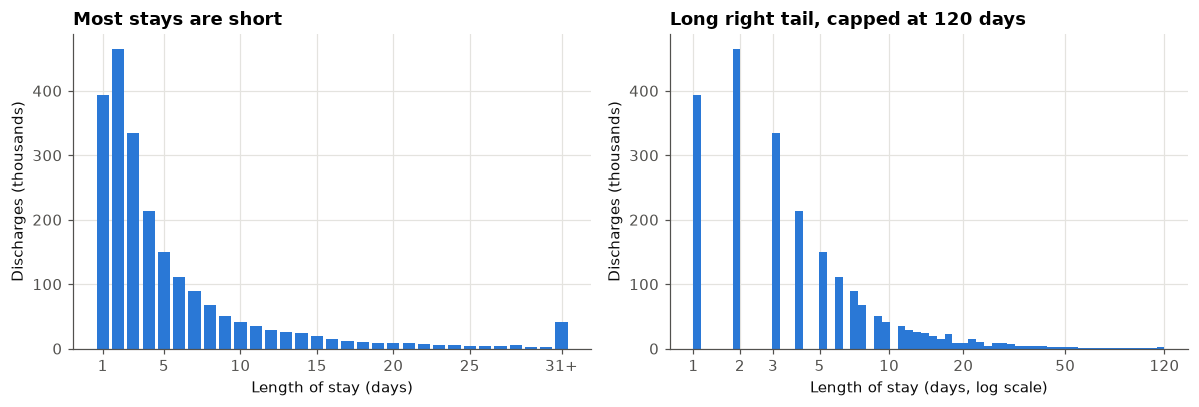

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

counts = los.clip(upper=31).value_counts().sort_index()
axes[0].bar(counts.index, counts.values / 1e3, color=BLUE, width=0.8)
axes[0].set_xticks([1, 5, 10, 15, 20, 25, 31], ["1", "5", "10", "15", "20", "25", "31+"])
axes[0].set(title="Most stays are short", xlabel="Length of stay (days)", ylabel="Discharges (thousands)")

axes[1].hist(np.log1p(los), bins=60, color=BLUE, weights=np.full(len(los), 1e-3))
ticks = [1, 2, 3, 5, 10, 20, 50, 120]
axes[1].set_xticks(np.log1p(ticks), [str(t) for t in ticks])
axes[1].set(title="Long right tail, capped at 120 days", xlabel="Length of stay (days, log scale)", ylabel="Discharges (thousands)")
fig.tight_layout()
save(fig, "01_los_distribution")

LOS is heavily right-skewed (skewness about 6): the median is 3 days and the mean 5.8, and a small share of stays run to months. Squared-error loss would be dominated by those few long stays, so modeling `log1p(LOS)`, or a loss such as MAE, is worth considering. Stays recorded as "120+" are **censored**, meaning the true value is at least 120. They are only about 0.1% of rows, so we keep them at 120 and flag them.

## 2. Missing values

payment_typology_1               0.01
apr_medical_surgical             0.02
apr_risk_of_mortality            0.02
apr_severity_of_illness          0.02
apr_severity_of_illness_code     0.02
type_of_admission                0.17
facility_name                    0.24
health_service_area              0.24
permanent_facility_id            0.24
hospital_county                  0.24
zip_code                         1.91
ccsr_procedure_description      29.31
ccsr_procedure_code             29.31
birth_weight                    90.55
dtype: float64

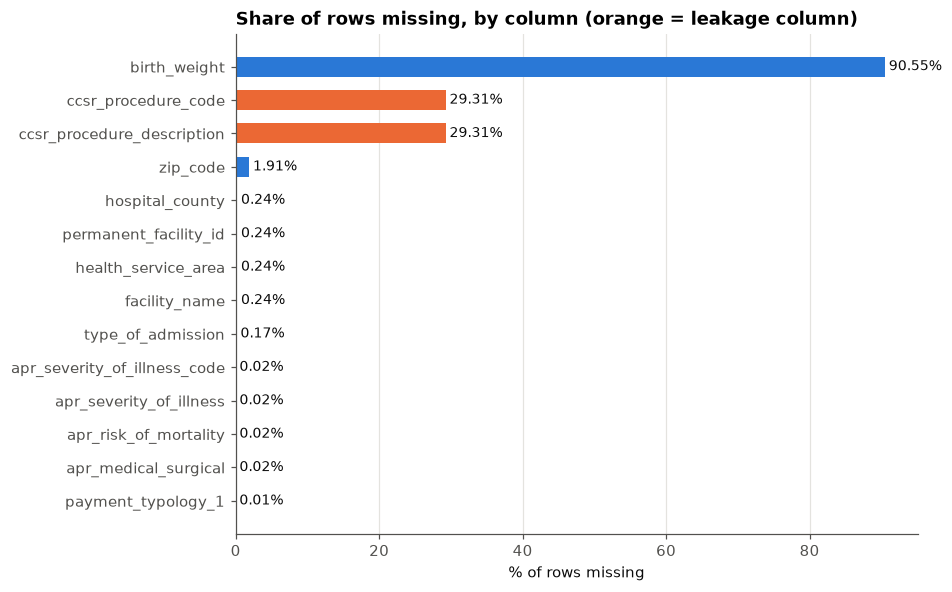

In [6]:
missing = df.isna().mean().mul(100).sort_values()
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 0.35 * len(missing) + 1))
colors = [ORANGE if c in LEAKAGE else BLUE for c in missing.index]
ax.barh(missing.index, missing.values, color=colors, height=0.6)
for y, v in enumerate(missing.values):
    ax.text(v + 0.5, y, f"{v:.2f}%", va="center", color=INK, fontsize=9)
ax.set(title="Share of rows missing, by column (orange = leakage column)", xlabel="% of rows missing")
ax.grid(axis="y", visible=False)
save(fig, "02_missingness")
missing.round(2)

- `birth_weight` is missing by design: it is recorded only for newborns.
- `ccsr_procedure_*` is missing when no procedure was done. This column is leakage anyway.
- Facility and location are missing for 5,295 rows (0.24%), which SPARCS redacts for confidentiality (flagged in `facility_redacted`).
- `zip_code` is missing for about 2% of rows. A further 3% are `"OOS"` (out of state), kept as its own level.
- Missing `payment_typology_2/3` was filled with `"None"` during cleaning (no secondary payer), so it no longer shows here.

## 3. LOS across admission-time features

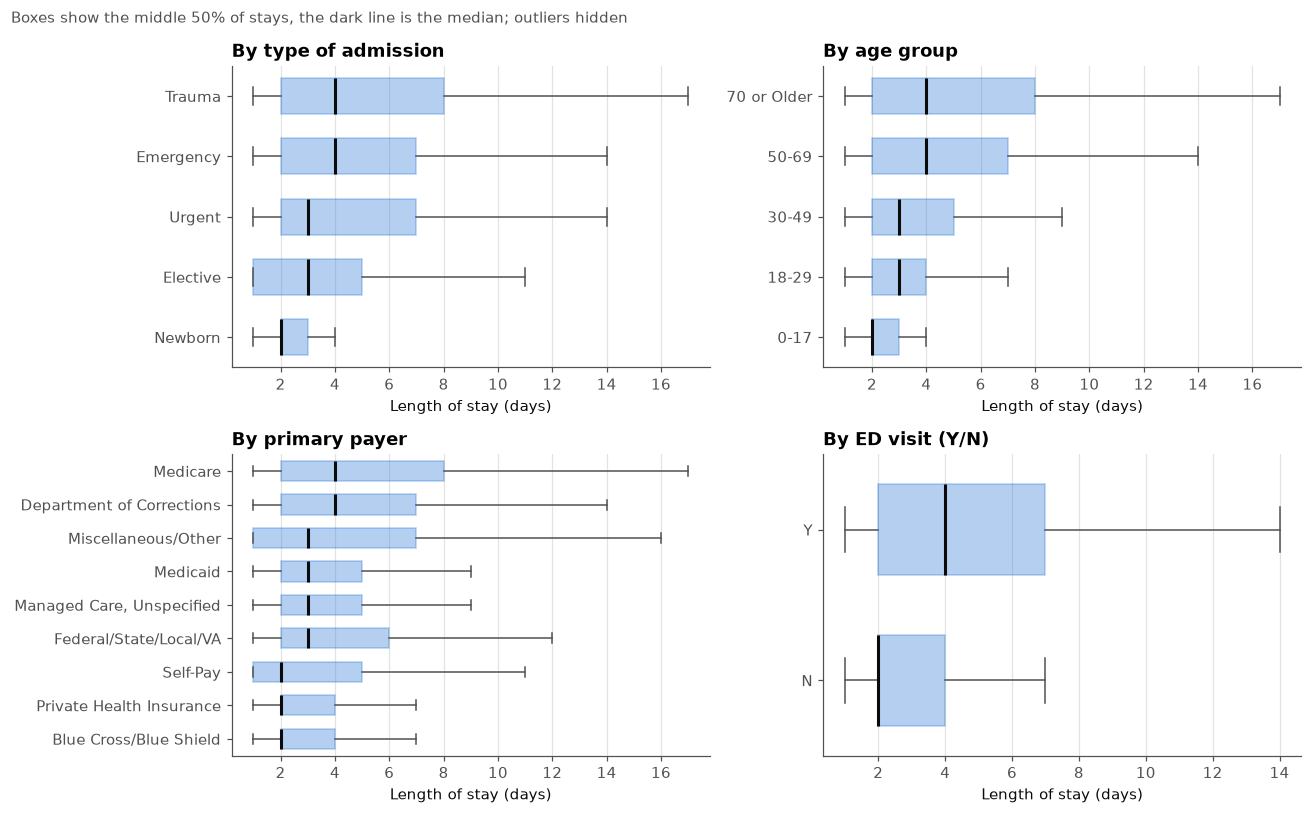

In [7]:
def los_by(ax, col, title=None, color=BLUE):
    data = df[[col, TARGET]].dropna()
    groups = data.groupby(col, observed=True)[TARGET]
    if isinstance(data[col].dtype, pd.CategoricalDtype) and data[col].cat.ordered:
        order = [c for c in data[col].cat.categories if c in groups.groups]
    else:
        order = groups.median().sort_values(kind="stable").index
    ax.boxplot([groups.get_group(g).values for g in order], orientation="horizontal", showfliers=False,
               widths=0.6, patch_artist=True,
               boxprops=dict(facecolor=color, edgecolor=color, alpha=0.35),
               medianprops=dict(color=INK, linewidth=2), whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
    ax.set_yticks(range(1, len(order) + 1), [str(o) for o in order])
    ax.set(title=title or col, xlabel="Length of stay (days)")
    ax.grid(axis="y", visible=False)


fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
los_by(axes[0, 0], "type_of_admission", title="By type of admission")
los_by(axes[0, 1], "age_group", title="By age group")
los_by(axes[1, 0], "payment_typology_1", title="By primary payer")
los_by(axes[1, 1], "emergency_department_indicator", title="By ED visit (Y/N)")
fig.suptitle("Boxes show the middle 50% of stays, the dark line is the median; outliers hidden",
             x=0.01, ha="left", color=MUTED, fontsize=10)
fig.tight_layout()
save(fig, "03_los_by_admission_features")

In [8]:
summary = {}
for col in ["type_of_admission", "age_group", "payment_typology_1", "emergency_department_indicator", "gender"]:
    summary[col] = df.groupby(col, observed=True)[TARGET].agg(["count", "median", "mean"]).round(2)
pd.concat(summary, names=["feature", "level"])

count  median  \
feature                        level                                        
type_of_admission              Elective                    355896     3.0   
                               Emergency                  1460204     4.0   
                               Newborn                     198219     2.0   
                               Trauma                       10050     4.0   
                               Urgent                      168716     3.0   
age_group                      0-17                        301927     2.0   
                               18-29                       183237     3.0   
                               30-49                       423270     3.0   
                               50-69                       581333     4.0   
                               70 or Older                 706970     4.0   
payment_typology_1             Blue Cross/Blue Shield      204165     2.0   
                               Department of Corrections     1635     4.0   
                               Federal/State/Local/VA       21140     3.0   
                               Managed Care, Unspecified    30320     3.0   
                               Medicaid                    635606     3.0   
                               Medicare                    929267     4.0   
                               Miscellaneous/Other          21764     3.0   
                               Private Health Insurance    317827     2.0   
                               Self-Pay                     34786     2.0   
emergency_department_indicator N                           819596     2.0   
                               Y                          1377141     4.0   
gender                         F                          1195617     3.0   
                               M                          1000735     3.0   
                               U                              385     2.0   

                                                          mean  
feature                        level                            
type_of_admission              Elective                   4.89  
                               Emergency                  6.21  
                               Newborn                    3.55  
                               Trauma                     7.17  
                               Urgent                     6.82  
age_group                      0-17                       4.01  
                               18-29                      4.82  
                               30-49                      5.19  
                               50-69                      6.64  
                               70 or Older                6.53  
payment_typology_1             Blue Cross/Blue Shield     4.27  
                               Department of Corrections  6.33  
                               Federal/State/Local/VA     5.39  
                               Managed Care, Unspecified  4.90  
                               Medicaid                   5.78  
                               Medicare                   6.69  
                               Miscellaneous/Other        6.32  
                               Private Health Insurance   4.51  
                               Self-Pay                   4.61  
emergency_department_indicator N                          5.04  
                               Y                          6.27  
gender                         F                          5.32  
                               M                          6.39  
                               U                          4.57

- **Age:** median LOS rises from 2 days (0-17) to 4 days (50+), and the mean from 4.0 to about 6.6.
- **Admission type / ED:** emergency and trauma admissions, and admissions through the ED, stay longer than elective ones. Newborn stays are the shortest.
- **Payer:** Medicare (mostly 65+) has the longest stays and private insurance the shortest, so payer partly stands in for age and health.
- **Gender:** men stay about 1 day longer on average (6.4 vs 5.3 days), with the same median.

Each feature shifts LOS in the expected direction, but the boxes overlap heavily. On their own, demographics explain little, so diagnosis is likely to carry most of the signal.

### Diagnosis (CCSR) and facility

,n,median_los,mean_los,description
ccsr_diagnosis_code,,,,
PRG022,26758,2.0,2.51,PROLONGED PREGNANCY
PRG023,37039,2.0,2.51,COMPLICATIONS SPECIFIED DURING CHILDBIRTH
MUS006,28954,2.0,2.80,OSTEOARTHRITIS
PNL001,199274,2.0,3.54,LIVEBORN
CIR017,37083,2.0,3.69,CARDIAC DYSRHYTHMIAS
NVS009,25626,2.0,4.20,EPILEPSY; CONVULSIONS
MUS011,31909,3.0,4.49,SPONDYLOPATHIES/SPONDYLOARTHROPATHY (INCLUDING...
END011,25487,3.0,4.51,FLUID AND ELECTROLYTE DISORDERS
SKN001,29222,3.0,4.56,SKIN AND SUBCUTANEOUS TISSUE INFECTIONS


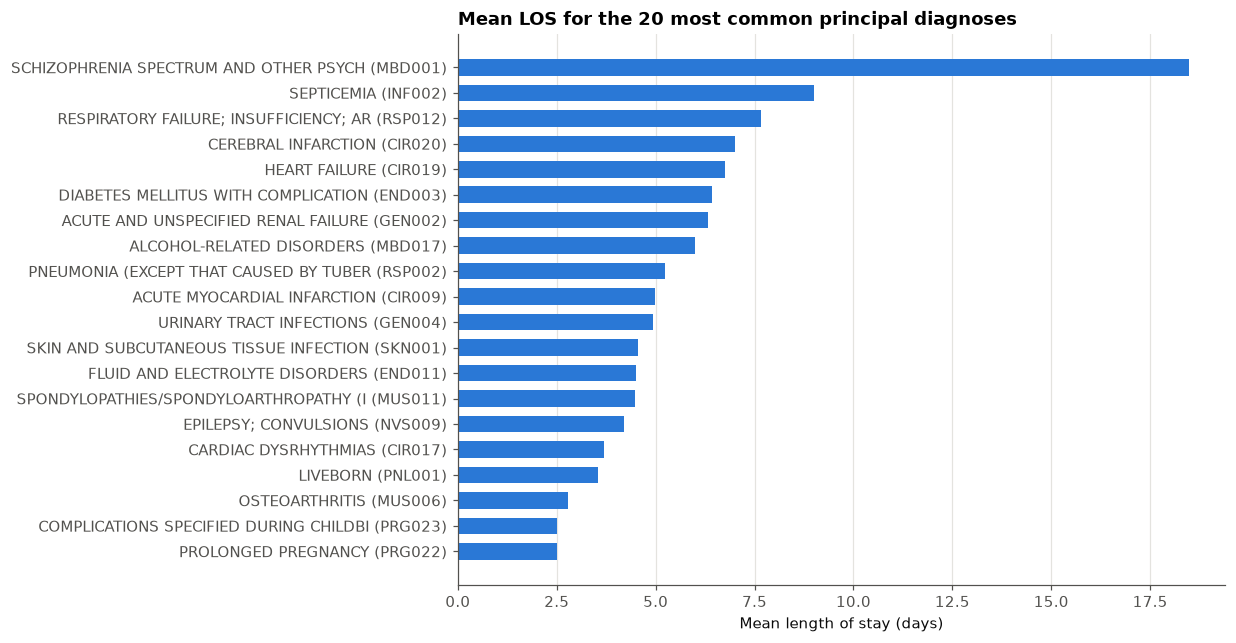

In [9]:
top_dx = df["ccsr_diagnosis_code"].value_counts().head(20).index
dx = (df[df["ccsr_diagnosis_code"].isin(top_dx)]
      .groupby("ccsr_diagnosis_code", observed=True)
      .agg(n=(TARGET, "size"), median_los=(TARGET, "median"), mean_los=(TARGET, "mean"),
           description=("ccsr_diagnosis_description", "first"))
      .sort_values("mean_los"))

fig, ax = plt.subplots(figsize=(9, 6.5))
labels = [f"{str(d)[:38]} ({c})" for c, d in zip(dx.index, dx["description"])]
ax.barh(labels, dx["mean_los"], color=BLUE, height=0.65)
ax.set(title="Mean LOS for the 20 most common principal diagnoses", xlabel="Mean length of stay (days)")
ax.grid(axis="y", visible=False)
save(fig, "04_los_by_top_diagnoses")
dx.round(2)

Principal diagnosis separates stays far more than demographics do: among the 20 most common diagnoses, the mean LOS ranges from about 2.5 days (pregnancy-related) to about 18 days (schizophrenia spectrum).

count    176.00
mean       5.96
std        2.84
min        2.51
25%        4.39
50%        5.32
75%        6.58
max       24.89
Name: mean, dtype: float64

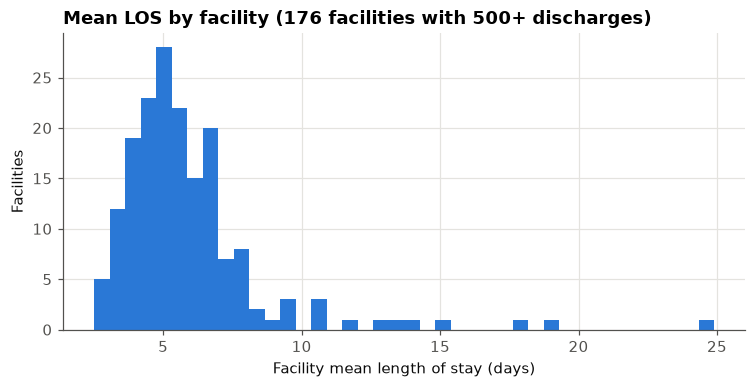

In [10]:
fac = df.groupby("permanent_facility_id", observed=True)[TARGET].agg(["size", "mean"])
fac = fac[fac["size"] >= 500]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(fac["mean"], bins=40, color=BLUE)
ax.set(title=f"Mean LOS by facility ({len(fac)} facilities with 500+ discharges)",
       xlabel="Facility mean length of stay (days)", ylabel="Facilities")
save(fig, "05_los_by_facility")
fac["mean"].describe().round(2)

Facility matters as well: among the 176 facilities with 500+ discharges, mean LOS ranges from about 2.5 to about 25 days (median 5.3). Part of this is case mix (specialty and psychiatric hospitals), which makes facility a useful but high-cardinality feature.

## 4. Cardinality of categorical features

emergency_department_indicator      2
gender                              3
ethnicity                           4
race                                4
type_of_admission                   5
age_group                           5
health_service_area                 8
payment_typology_1                  9
payment_typology_3                 10
payment_typology_2                 10
zip_code                           50
hospital_county                    57
permanent_facility_id             205
ccsr_diagnosis_code               478
dtype: int64

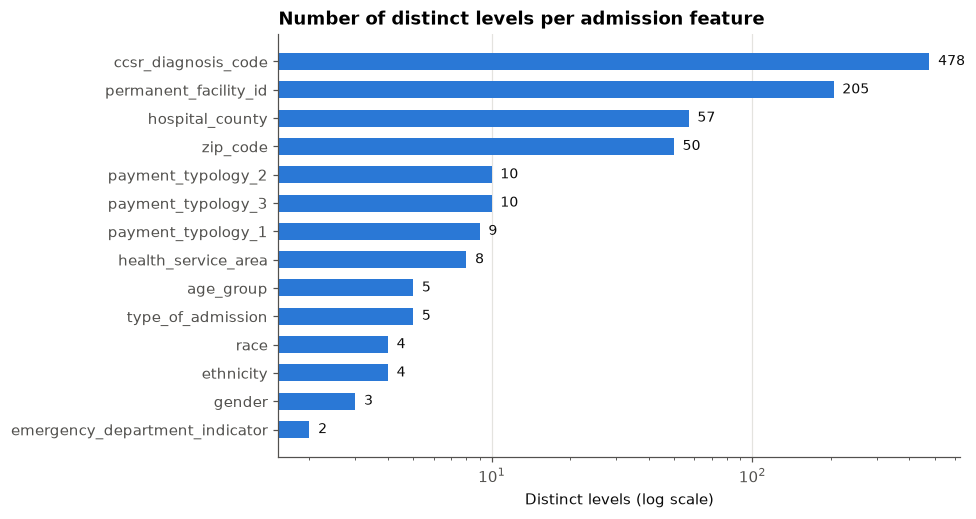

In [11]:
card = df[[c for c in ADMISSION_FEATURES if c != "birth_weight"]].nunique().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(card.index, card.values, color=BLUE, height=0.6)
for y, v in enumerate(card.values):
    ax.text(v * 1.08, y, f"{v:,}", va="center", color=INK, fontsize=9)
ax.set_xscale("log")
ax.set(title="Number of distinct levels per admission feature", xlabel="Distinct levels (log scale)")
ax.grid(axis="y", visible=False)
save(fig, "06_cardinality")
card

Most features have under 10 levels, so one-hot encoding is fine for them. `ccsr_diagnosis_code` (about 480 levels), `permanent_facility_id` (about 205), `zip_code`, and `hospital_county` have many more. These need target encoding (fit inside CV folds to avoid leakage), grouping rare levels, or a model that handles categoricals natively (for example HistGradientBoosting or LightGBM).

## 5. Newborns

Newborn admissions: 198,219 (9.0%)
has birth weight     False   True 
newborn admission                 
False              1988890    9628
True                   147  198072


,size,median,mean
birth_weight,,,
<1000,1139,71.0,63.03
1000-1499,1579,42.0,44.73
1500-1999,3473,17.0,20.56
2000-2499,12454,3.0,6.38
2500-2999,42568,2.0,2.99
3000-3499,81743,2.0,2.37
3500-3999,51095,2.0,2.29
4000+,13649,2.0,2.55


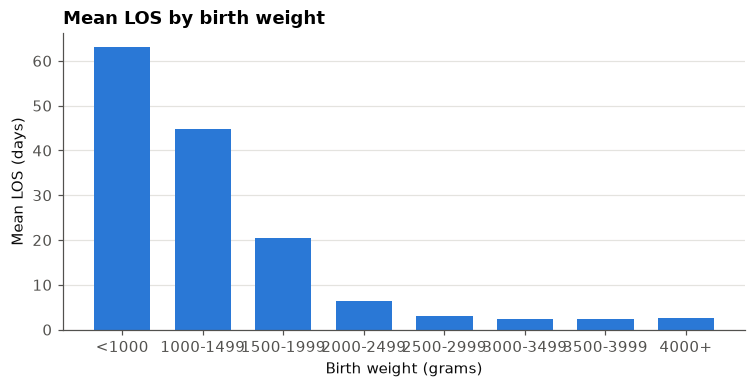

In [12]:
newborn = df["type_of_admission"].eq("Newborn")
print(f"Newborn admissions: {newborn.sum():,} ({newborn.mean():.1%})")
print(pd.crosstab(newborn, df["birth_weight"].notna(), rownames=["newborn admission"], colnames=["has birth weight"]))

bw = df.loc[df["birth_weight"].notna(), ["birth_weight", TARGET]]
bins = pd.cut(bw["birth_weight"], [0, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 10000], right=False,
              labels=["<1000", "1000-1499", "1500-1999", "2000-2499", "2500-2999", "3000-3499", "3500-3999", "4000+"])
by_bw = bw.groupby(bins, observed=True)[TARGET].agg(["size", "median", "mean"])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(by_bw.index.astype(str), by_bw["mean"], color=BLUE, width=0.7)
ax.set(title="Mean LOS by birth weight", xlabel="Birth weight (grams)", ylabel="Mean LOS (days)")
ax.grid(axis="x", visible=False)
save(fig, "07_newborn_birth_weight")
by_bw.round(2)

The effect is very large: babies under 1,500 g average about 52 days, 1,500-2,499 g about 9.5 days, and 2,500 g or more about 2.5 days. Birth weight is known at birth and is recorded only for about 207k rows: mostly newborn admissions, plus about 9.6k other infant admissions. It is meaningful only for this subgroup, so the model needs either a "has birth weight" indicator plus an imputed value, or a separate newborn model.

## 6. Leakage check: why these columns are excluded

total_charges                   0.591
total_costs                     0.664
apr_severity_of_illness_code    0.463
Name: length_of_stay, dtype: float64

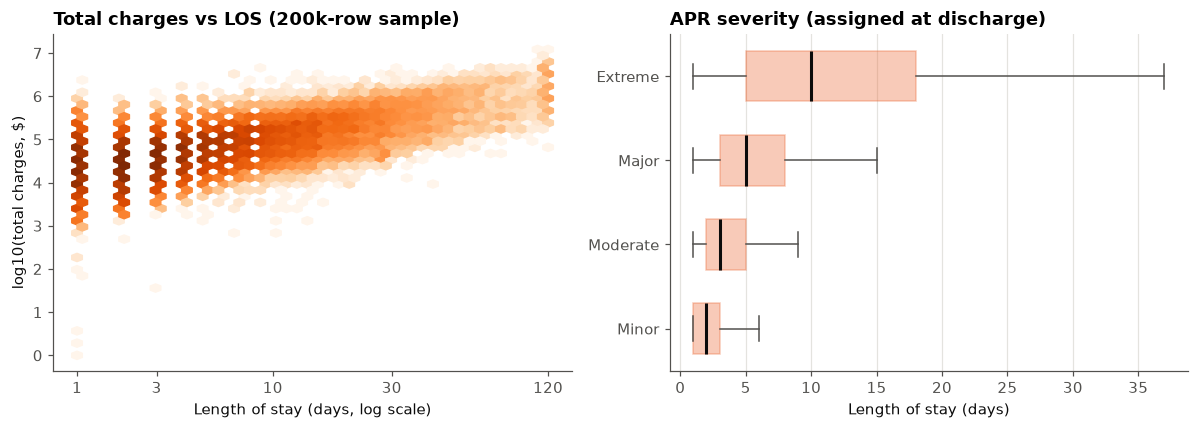

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sample = df[[TARGET, "total_charges"]].dropna().sample(200_000, random_state=0)
axes[0].hexbin(np.log1p(sample[TARGET]), np.log10(sample["total_charges"].clip(lower=1)),
               gridsize=45, cmap="Oranges", mincnt=1, bins="log")
ticks = [1, 3, 10, 30, 120]
axes[0].set_xticks(np.log1p(ticks), [str(t) for t in ticks])
axes[0].set(title="Total charges vs LOS (200k-row sample)", xlabel="Length of stay (days, log scale)",
            ylabel="log10(total charges, $)")
axes[0].grid(False)

los_by(axes[1], "apr_severity_of_illness", title="APR severity (assigned at discharge)", color=ORANGE)
fig.tight_layout()
save(fig, "08_leakage_examples")

leak_num = ["total_charges", "total_costs", "apr_severity_of_illness_code"]
df[leak_num + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET).round(3)

Charges and costs have Spearman correlations of about 0.59 and 0.66 with LOS, and APR severity about 0.46. Each of these is higher than anything an admission feature can be expected to reach. Charges and costs are *outcomes* of LOS (a longer stay produces a bigger bill), so the correlation is circular. APR severity, risk of mortality, DRG, and MDC come from the 3M APR-DRG grouper run on the discharge record, and disposition and procedures are known only after the stay. None of these are available at admission, so all are excluded from the features (`LEAKAGE` in `src/config.py`).

## Takeaways for modeling
1. **Target:** heavily right-skewed. Consider training on `log1p(LOS)` and reporting errors in days. The 120+ cap affects about 0.1% of rows.
2. **Features:** use only the admission features. Diagnosis is expected to be the strongest signal and comes with the principal-diagnosis caveat.
3. **Encoding:** one-hot the low-cardinality features. Target-encode (inside CV) or use native categorical support for diagnosis, facility, and zip.
4. **Newborns:** birth weight is informative but only defined for infants.
5. **Splitting:** with 2.2M rows, a simple train/validation/test split is enough. Stratify on binned LOS so the long tail appears in every split.